In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sklearn as skl
import joblib
from sklearn.metrics import confusion_matrix

# CSI Processing and Classification Notebook

This notebook processes CSI CSV files, extracts features, normalizes them, builds datasets and trains a Random Forest 
classifier to detect presence/absence of a person.

Overview of main sections:
- Mount drive and define file paths (cell 3).
- Parse CSI, convert to complex values and compute magnitudes (cell 4).
- Load and process all files into magnitude matrices (cells 5-6).
- Extract subcarrier slices, compute per-ESP normalization means (cells 7-8) and save with joblib.
- Build sample dictionaries per subcarrier and group (cells 8-9).
- Normalize vectors using precomputed means (cell 9).
- Compute sliding-window features (mean, std, max) with fixed/truncated windows (cells 10-13).
- Assemble feature columns and build two DataFrames:
  - df - main training dataset (cells 14-16)
  - df_afinar - small refinement dataset (cell 16)
- Train Random Forest, save model and evaluate (cells 17-28).
- Optionally perform grid search over Random Forest hyperparameters and save results (cells 31-34).

Notes:
- Required libraries: pandas, numpy, matplotlib, scikit-learn, joblib, seaborn. Google Colab drive mount is used to access CSVs.
- Cells assume shared state: imports, variables and functions defined in earlier cells are reused.
- Adjust parameters (window sizes W/G, subcarriers, groups) near the top cells as needed before re-running the pipeline.

In [24]:
path = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project\\CSI DATA D&M"

files_csi = {
    'sem_pessoa': {
        'esp1': path + '\\user00_positionz00_esp01_2025-04-01_02.csv',
        'esp2': path + '\\user00_positionz00_esp02_2025-04-01_02.csv',
        'esp3': path + '\\user00_positionz00_esp03_2025-04-01_02.csv',
        'esp4': path + '\\user00_positionz00_esp04_2025-04-01_02.csv',
    },
    'sem_pessoa_1': {
        'esp1': path + '\\00_z00_esp1_2025-06-24.csv',
        'esp2': path + '\\00_z00_esp2_2025-06-24.csv',
        'esp3': path + '\\00_z00_esp3_2025-06-24.csv',
        'esp4': path + '\\00_z00_esp4_2025-06-24.csv',
    },
    'd04': {
        'esp1': path + '\\user01_positiond04_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond04_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond04_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond04_esp4_2025-04-02.csv',
    },
    'd09': {
        'esp1': path + '\\user01_positiond09_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond09_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond09_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond09_esp4_2025-04-02.csv',
    },
    'c06': {
        'esp1': path + '\\user01_positionc06_esp1_2025-04-30.csv',
        'esp2': path + '\\user01_positionc06_esp2_2025-04-30.csv',
        'esp3': path + '\\user01_positionc06_esp3_2025-04-30.csv',
        'esp4': path + '\\user01_positionc06_esp4_2025-04-30.csv',
    },
    'a02': {
        'esp1': path + '\\user01_positiona02_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positiona02_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positiona02_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positiona02_esp04_2025-04-01.csv',
    },
    'b07': {
        'esp1': path + '\\user01_positionb07_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb07_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb07_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb07_esp04_2025-04-01.csv',
    },
    'a00': {
        'esp1': path + '\\user01_positiona00_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positiona00_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positiona00_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positiona00_esp04_2025-04-01.csv',
    },
    'a01': {
        'esp1': path + '\\user01_positiona01_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positiona01_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positiona01_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positiona01_esp04_2025-04-01.csv',
    },
    'a09': {
        'esp1': path + '\\user01_positiona09_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positiona09_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positiona09_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positiona09_esp04_2025-04-01.csv',
    },
    'a10': {
        'esp1': path + '\\user01_positiona10_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positiona10_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positiona10_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positiona10_esp04_2025-04-01.csv',
    },
    'a11': {
        'esp1': path + '\\user01_positiona11_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positiona11_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positiona11_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positiona11_esp04_2025-04-01.csv',
    },
    'b00': {
        'esp1': path + '\\user01_positionb00_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb00_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb00_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb00_esp04_2025-04-01.csv',
    },
    'b01': {
        'esp1': path + '\\user01_positionb01_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb01_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb01_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb01_esp04_2025-04-01.csv',
    },
    'b02': {
        'esp1': path + '\\user01_positionb02_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb02_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb02_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb02_esp04_2025-04-01.csv',
    },
    'b03': {
        'esp1': path + '\\user01_positionb03_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb03_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb03_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb03_esp04_2025-04-01.csv',
    },
    'b04': {
        'esp1': path + '\\user01_positionb04_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb04_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb04_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb04_esp04_2025-04-01.csv',
    },
    'b05': {
        'esp1': path + '\\user01_positionb05_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb05_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb05_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb05_esp04_2025-04-01.csv',
    },
    'b06': {
        'esp1': path + '\\user01_positionb06_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb06_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb06_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb06_esp04_2025-04-01.csv',
    },
    'b08': {
        'esp1': path + '\\user01_positionb08_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb08_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb08_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb08_esp04_2025-04-01.csv',
    },
    'b09': {
        'esp1': path + '\\user01_positionb09_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb09_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb09_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb09_esp04_2025-04-01.csv',
    },
    'b10': {
        'esp1': path + '\\user01_positionb10_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb10_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb10_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb10_esp04_2025-04-01.csv',
    },
    'b11': {
        'esp1': path + '\\user01_positionb01_esp01_2025-04-01.csv',
        'esp2': path + '\\user01_positionb01_esp02_2025-04-01.csv',
        'esp3': path + '\\user01_positionb01_esp03_2025-04-01.csv',
        'esp4': path + '\\user01_positionb01_esp04_2025-04-01.csv',
    },
    'c01': {
        'esp1': path + '\\user01_positionc01_esp01_2025-04-02.csv',
        'esp2': path + '\\user01_positionc01_esp02_2025-04-02.csv',
        'esp3': path + '\\user01_positionc01_esp03_2025-04-02.csv',
        'esp4': path + '\\user01_positionc01_esp04_2025-04-02.csv',
    },
    'c02': {
        'esp1': path + '\\user01_positionc02_esp01_2025-04-02.csv',
        'esp2': path + '\\user01_positionc02_esp02_2025-04-02.csv',
        'esp3': path + '\\user01_positionc02_esp03_2025-04-02.csv',
        'esp4': path + '\\user01_positionc02_esp04_2025-04-02.csv',
    },
    'c03': {
        'esp1': path + '\\user01_positionc03_esp01_2025-04-02.csv',
        'esp2': path + '\\user01_positionc03_esp02_2025-04-02.csv',
        'esp3': path + '\\user01_positionc03_esp03_2025-04-02.csv',
        'esp4': path + '\\user01_positionc03_esp04_2025-04-02.csv',
    },
    'c04': {
        'esp1': path + '\\user01_positionc04_esp01_2025-04-02.csv',
        'esp2': path + '\\user01_positionc04_esp02_2025-04-02.csv',
        'esp3': path + '\\user01_positionc04_esp03_2025-04-02.csv',
        'esp4': path + '\\user01_positionc04_esp04_2025-04-02.csv',
    },
    'c05': {
        'esp1': path + '\\user01_positionc05_esp01_2025-04-02.csv',
        'esp2': path + '\\user01_positionc05_esp02_2025-04-02.csv',
        'esp3': path + '\\user01_positionc05_esp03_2025-04-02.csv',
        'esp4': path + '\\user01_positionc05_esp04_2025-04-02.csv',
    },
    'c07': {
        'esp1': path + '\\user01_positionc07_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positionc07_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positionc07_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positionc07_esp4_2025-04-02.csv',
    },
    'c08': {
        'esp1': path + '\\user01_positionc08_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positionc08_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positionc08_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positionc08_esp4_2025-04-02.csv',
    },
    'c09': {
        'esp1': path + '\\user01_positionc09_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positionc09_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positionc09_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positionc09_esp4_2025-04-02.csv',
    },
    'c10': {
        'esp1': path + '\\user01_positionc10_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positionc10_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positionc10_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positionc10_esp4_2025-04-02.csv',
    },
    'c11': {
        'esp1': path + '\\user01_positionc11_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positionc11_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positionc11_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positionc11_esp4_2025-04-02.csv',
    },
    'd01': {
        'esp1': path + '\\user01_positiond01_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond01_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond01_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond01_esp4_2025-04-02.csv',
    },
    'd02': {
        'esp1': path + '\\user01_positiond02_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond02_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond02_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond02_esp4_2025-04-02.csv',
    },
    'd03': {
        'esp1': path + '\\user01_positiond03_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond03_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond03_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond03_esp4_2025-04-02.csv',
    },
    'd05': {
        'esp1': path + '\\user01_positiond05_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond05_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond05_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond05_esp4_2025-04-02.csv',
    },
    'd06': {
        'esp1': path + '\\user01_positiond06_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond06_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond06_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond06_esp4_2025-04-02.csv',
    },
    'd07': {
        'esp1': path + '\\user01_positiond07_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond07_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond07_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond07_esp4_2025-04-02.csv',
    },
    'd08': {
        'esp1': path + '\\user01_positiond08_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond08_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond08_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond08_esp4_2025-04-02.csv',
    },
    'd10': {
        'esp1': path + '\\user01_positiond10_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond10_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond10_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond10_esp4_2025-04-02.csv',
    },
    'd11': {
        'esp1': path + '\\user01_positiond11_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positiond11_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positiond11_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positiond11_esp4_2025-04-02.csv',
    },
    'e04': {
        'esp1': path + '\\user01_positione04_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positione04_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positione04_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positione04_esp4_2025-04-02.csv',
    },
    'e05': {
        'esp1': path + '\\user01_positione05_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positione05_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positione05_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positione05_esp4_2025-04-02.csv',
    },
    'e06': {
        'esp1': path + '\\user01_positione06_esp1_2025-04-02.csv',
        'esp2': path + '\\user01_positione06_esp2_2025-04-02.csv',
        'esp3': path + '\\user01_positione06_esp3_2025-04-02.csv',
        'esp4': path + '\\user01_positione06_esp4_2025-04-02.csv',
    }
}

files_diana = {
    'a02': {
        'esp1': path + '\\02_a02_esp1.csv',
        'esp2': path + '\\02_a02_esp2.csv',
        'esp3': path + '\\02_a02_esp3.csv',
        'esp4': path + '\\02_a02_esp4.csv',
    },
    'b07': {
        'esp1': path + '\\02_b07_esp1.csv',
        'esp2': path + '\\02_b07_esp2.csv',
        'esp3': path + '\\02_b07_esp3.csv',
        'esp4': path + '\\02_b07_esp4.csv',
    },
    'd04': {
        'esp1': path + '\\02_d04_esp1.csv',
        'esp2': path + '\\02_d04_esp2.csv',
        'esp3': path + '\\02_d04_esp3.csv',
        'esp4': path + '\\02_d04_esp4.csv',
    },
    'd09': {
        'esp1': path + '\\02_d09_esp1.csv',
        'esp2': path + '\\02_d09_esp2.csv',
        'esp3': path + '\\02_d09_esp3.csv',
        'esp4': path + '\\02_d09_esp4.csv',
    },
    'sem_pessoa': {
        'esp1': path + '\\20250602-103346_00_z00_esp1.csv',
        'esp2': path + '\\20250602-103346_00_z00_esp2.csv',
        'esp3': path + '\\20250602-103346_00_z00_esp3.csv',
        'esp4': path + '\\20250602-103346_00_z00_esp4.csv',
    },
    'sem_pessoa_1': {
        'esp1': path + '\\00_z00_esp1_2025-06-24 (1).csv',
        'esp2': path + '\\00_z00_esp2_2025-06-24 (1).csv',
        'esp3': path + '\\00_z00_esp3_2025-06-24 (1).csv',
        'esp4': path + '\\00_z00_esp4_2025-06-24 (1).csv',
    },
    'a00': {
        'esp1': path + '\\02_a02_esp1.csv',
        'esp2': path + '\\02_a02_esp2.csv',
        'esp3': path + '\\02_a02_esp3.csv',
        'esp4': path + '\\02_a02_esp4.csv',
    },
    'a01': {
        'esp1': path + '\\02_a02_esp1.csv',
        'esp2': path + '\\02_a02_esp2.csv',
        'esp3': path + '\\02_a02_esp3.csv',
        'esp4': path + '\\02_a02_esp4.csv',
    },
    'a09': {
        'esp1': path + '\\02_a09_esp1.csv',
        'esp2': path + '\\02_a09_esp2.csv',
        'esp3': path + '\\02_a09_esp3.csv',
        'esp4': path + '\\02_a09_esp4.csv',
    },
    'a10': {
        'esp1': path + '\\02_a10_esp1.csv',
        'esp2': path + '\\02_a10_esp2.csv',
        'esp3': path + '\\02_a10_esp3.csv',
        'esp4': path + '\\02_a10_esp4.csv',
    },
    'a11': {
        'esp1': path + '\\02_a11_esp1.csv',
        'esp2': path + '\\02_a11_esp2.csv',
        'esp3': path + '\\02_a11_esp3.csv',
        'esp4': path + '\\02_a11_esp4.csv',
    },
    'b00': {
        'esp1': path + '\\02_b00_esp1.csv',
        'esp2': path + '\\02_b00_esp2.csv',
        'esp3': path + '\\02_b00_esp3.csv',
        'esp4': path + '\\02_b00_esp4.csv',
    },
    'b01': {
        'esp1': path + '\\02_b01_esp1.csv',
        'esp2': path + '\\02_b01_esp2.csv',
        'esp3': path + '\\02_b01_esp3.csv',
        'esp4': path + '\\02_b01_esp4.csv',
    },
    'b02': {
        'esp1': path + '\\02_b02_esp1.csv',
        'esp2': path + '\\02_b02_esp2.csv',
        'esp3': path + '\\02_b02_esp3.csv',
        'esp4': path + '\\02_b02_esp4.csv',
    },
    'b03': {
        'esp1': path + '\\02_b03_esp1.csv',
        'esp2': path + '\\02_b03_esp2.csv',
        'esp3': path + '\\02_b03_esp3.csv',
        'esp4': path + '\\02_b03_esp4.csv',
    },
    'b04': {
        'esp1': path + '\\02_b04_esp1.csv',
        'esp2': path + '\\02_b04_esp2.csv',
        'esp3': path + '\\02_b04_esp3.csv',
        'esp4': path + '\\02_b04_esp4.csv',
    },
    'b05': {
        'esp1': path + '\\02_b05_esp1.csv',
        'esp2': path + '\\02_b05_esp2.csv',
        'esp3': path + '\\02_b05_esp3.csv',
        'esp4': path + '\\02_b05_esp4.csv',
    },
    'b06': {
        'esp1': path + '\\02_b06_esp1.csv',
        'esp2': path + '\\02_b06_esp2.csv',
        'esp3': path + '\\02_b06_esp3.csv',
        'esp4': path + '\\02_b06_esp4.csv',
    },
    'b08': {
        'esp1': path + '\\02_b08_esp1.csv',
        'esp2': path + '\\02_b08_esp2.csv',
        'esp3': path + '\\02_b08_esp3.csv',
        'esp4': path + '\\02_b08_esp4.csv',
    },
    'b09': {
        'esp1': path + '\\02_b09_esp1.csv',
        'esp2': path + '\\02_b09_esp2.csv',
        'esp3': path + '\\02_b09_esp3.csv',
        'esp4': path + '\\02_b09_esp4.csv',
    },
    'b10': {
        'esp1': path + '\\02_b10_esp1.csv',
        'esp2': path + '\\02_b10_esp2.csv',
        'esp3': path + '\\02_b10_esp3.csv',
        'esp4': path + '\\02_b10_esp4.csv',
    },
    'b11': {
        'esp1': path + '\\02_b11_esp1.csv',
        'esp2': path + '\\02_b11_esp2.csv',
        'esp3': path + '\\02_b11_esp3.csv',
        'esp4': path + '\\02_b11_esp4.csv',
    },
    'c01': {
        'esp1': path + '\\02_c01_esp1.csv',
        'esp2': path + '\\02_c01_esp2.csv',
        'esp3': path + '\\02_c01_esp3.csv',
        'esp4': path + '\\02_c01_esp4.csv',
    },
    'c02': {
        'esp1': path + '\\02_c02_esp1.csv',
        'esp2': path + '\\02_c02_esp2.csv',
        'esp3': path + '\\02_c02_esp3.csv',
        'esp4': path + '\\02_c02_esp4.csv',
    },
    'c03': {
        'esp1': path + '\\02_c03_esp1.csv',
        'esp2': path + '\\02_c03_esp2.csv',
        'esp3': path + '\\02_c03_esp3.csv',
        'esp4': path + '\\02_c03_esp4.csv',
    },
    'c04': {
        'esp1': path + '\\02_c04_esp1.csv',
        'esp2': path + '\\02_c04_esp2.csv',
        'esp3': path + '\\02_c04_esp3.csv',
        'esp4': path + '\\02_c04_esp4.csv',
    },
    'c05': {
        'esp1': path + '\\02_c05_esp1.csv',
        'esp2': path + '\\02_c05_esp2.csv',
        'esp3': path + '\\02_c05_esp3.csv',
        'esp4': path + '\\02_c05_esp4.csv',
    },
    'c06': {
        'esp1': path + '\\02_c06_esp1.csv',
        'esp2': path + '\\02_c06_esp2.csv',
        'esp3': path + '\\02_c06_esp3.csv',
        'esp4': path + '\\02_c06_esp4.csv',
    },
    'c07': {
        'esp1': path + '\\02_c07_esp1.csv',
        'esp2': path + '\\02_c07_esp2.csv',
        'esp3': path + '\\02_c07_esp3.csv',
        'esp4': path + '\\02_c07_esp4.csv',
    },
    'c08': {
        'esp1': path + '\\02_c08_esp1.csv',
        'esp2': path + '\\02_c08_esp2.csv',
        'esp3': path + '\\02_c08_esp3.csv',
        'esp4': path + '\\02_c08_esp4.csv',
    },
    'c09': {
        'esp1': path + '\\02_c09_esp1.csv',
        'esp2': path + '\\02_c09_esp2.csv',
        'esp3': path + '\\02_c09_esp3.csv',
        'esp4': path + '\\02_c09_esp4.csv',
    },
    'c10': {
        'esp1': path + '\\02_c10_esp1.csv',
        'esp2': path + '\\02_c10_esp2.csv',
        'esp3': path + '\\02_c10_esp3.csv',
        'esp4': path + '\\02_c10_esp4.csv',
    },
    'c11': {
        'esp1': path + '\\02_c11_esp1.csv',
        'esp2': path + '\\02_c11_esp2.csv',
        'esp3': path + '\\02_c11_esp3.csv',
        'esp4': path + '\\02_c11_esp4.csv',
    },
    'd01': {
        'esp1': path + '\\02_d01_esp1.csv',
        'esp2': path + '\\02_d01_esp2.csv',
        'esp3': path + '\\02_d01_esp3.csv',
        'esp4': path + '\\02_d01_esp4.csv',
    },
    'd02': {
        'esp1': path + '\\02_d02_esp1.csv',
        'esp2': path + '\\02_d02_esp2.csv',
        'esp3': path + '\\02_d02_esp3.csv',
        'esp4': path + '\\02_d02_esp4.csv',
    },
    'd03': {
        'esp1': path + '\\02_d03_esp1.csv',
        'esp2': path + '\\02_d03_esp2.csv',
        'esp3': path + '\\02_d03_esp3.csv',
        'esp4': path + '\\02_d03_esp4.csv',
    },
    'd05': {
        'esp1': path + '\\02_d05_esp1.csv',
        'esp2': path + '\\02_d05_esp2.csv',
        'esp3': path + '\\02_d05_esp3.csv',
        'esp4': path + '\\02_d05_esp4.csv',
    },
    'd06': {
        'esp1': path + '\\02_d06_esp1.csv',
        'esp2': path + '\\02_d06_esp2.csv',
        'esp3': path + '\\02_d06_esp3.csv',
        'esp4': path + '\\02_d06_esp4.csv',
    },
    'd07': {
        'esp1': path + '\\02_d07_esp1.csv',
        'esp2': path + '\\02_d07_esp2.csv',
        'esp3': path + '\\02_d07_esp3.csv',
        'esp4': path + '\\02_d07_esp4.csv',
    },
    'd08': {
        'esp1': path + '\\02_d08_esp1.csv',
        'esp2': path + '\\02_d08_esp2.csv',
        'esp3': path + '\\02_d08_esp3.csv',
        'esp4': path + '\\02_d08_esp4.csv',
    },
    'd10': {
        'esp1': path + '\\02_d10_esp1.csv',
        'esp2': path + '\\02_d10_esp2.csv',
        'esp3': path + '\\02_d10_esp3.csv',
        'esp4': path + '\\02_d10_esp4.csv',
    },
    'd11': {
        'esp1': path + '\\02_d11_esp1.csv',
        'esp2': path + '\\02_d11_esp2.csv',
        'esp3': path + '\\02_d11_esp3.csv',
        'esp4': path + '\\02_d11_esp4.csv',
    },
    'e04': {
        'esp1': path + '\\02_e04_esp1.csv',
        'esp2': path + '\\02_e04_esp2.csv',
        'esp3': path + '\\02_e04_esp3.csv',
        'esp4': path + '\\02_e04_esp4.csv',
    },
    'e05': {
        'esp1': path + '\\02_e05_esp1.csv',
        'esp2': path + '\\02_e05_esp2.csv',
        'esp3': path + '\\02_e05_esp3.csv',
        'esp4': path + '\\02_e05_esp4.csv',
    },
    'e06': {
        'esp1': path + '\\02_e06_esp1.csv',
        'esp2': path + '\\02_e06_esp2.csv',
        'esp3': path + '\\02_e06_esp3.csv',
        'esp4': path + '\\02_e06_esp4.csv',
    }
}

files_afinar = {
    'com_pessoa': {
        'esp1': path + '\\01_afinar_2_esp1_2025-07-21.csv',
        'esp2': path + '\\01_afinar_2_esp2_2025-07-21.csv',
        'esp3': path + '\\01_afinar_2_esp3_2025-07-21.csv',
        'esp4': path + '\\01_afinar_2_esp4_2025-07-21.csv',
    },
    'sem_pessoa': {
        'esp1': path + '\\00_afinar_0_esp1_2025-07-21.csv',
        'esp2': path + '\\00_afinar_0_esp2_2025-07-21.csv',
        'esp3': path + '\\00_afinar_0_esp3_2025-07-21.csv',
        'esp4': path + '\\00_afinar_0_esp4_2025-07-21.csv',
    },
    'com_pessoa_2': {
        'esp1': path + '\\01_afinar_11_esp1_2025-07-21.csv',
        'esp2': path + '\\01_afinar_11_esp2_2025-07-21.csv',
        'esp3': path + '\\01_afinar_11_esp3_2025-07-21.csv',
        'esp4': path + '\\01_afinar_11_esp4_2025-07-21.csv',
    },
    'sem_pessoa_2': {
        'esp1': path + '\\00_afinar_00_esp1_2025-07-21.csv',
        'esp2': path + '\\00_afinar_00_esp2_2025-07-21.csv',
        'esp3': path + '\\00_afinar_00_esp3_2025-07-21.csv',
        'esp4': path + '\\00_afinar_00_esp4_2025-07-21.csv',
    }
}

In [25]:
# função que processo o arquivo CSV completo
# e extrai a info da coluna do CSI
# converte em números complexos e calcula a magnitude (2.º passo)

# faz ainda uma 1a limpeza (remover 2 primeiras subportadoras e colunas a zero)

def process_csi(file):
    df = pd.read_csv(file, header=None)
    csi_col = df.iloc[:, 26]  # Var27

    valid_csi = []
    for entry in csi_col:
        match = re.search(r'\[(.*?)\]', str(entry))
        if not match:
            continue
        nums = [float(n) for n in re.findall(r'-?\d+', match.group(1))]
        if len(nums) == 128:
            valid_csi.append(nums)

    valid_csi = np.array(valid_csi)
    complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]
    magnitudes = np.abs(complex_csi)

    # Limpeza: remover 2 primeiras subportadoras e colunas todas-zero
    magnitudes = magnitudes[:, 2:]
    magnitudes = magnitudes[:, ~np.all(magnitudes == 0, axis=0)]
    magnitudes = np.fft.fftshift(magnitudes, axes=1)

    return magnitudes

# função para calcular a média em janelas sobrepostas
def media_grupos_overlap(vetor, tamanho_janela = 10, step = 3):
    medias = []
    print("step f = ", step)
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        medias.append(np.mean(janela))
    return np.array(medias)

# função para calcular o desvio padrão em janelas sobrepostas
def std_grupos_overlap(vetor, tamanho_janela = 10, step = 3):
    desvios = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        desvios.append(np.std(janela))
    return np.array(desvios)

# função para calcular o máximo em janelas sobrepostas,
# evitando repetições dos últimos 3 máximos escolhidos
def max_grupos_overlap(vetor, tamanho_janela=10, step=3):
    maximos = []

    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        candidatos = np.sort(np.unique(janela))[::-1]  # do maior para o menor

        # Exclui os 3 últimos valores
        ultimos = set(maximos[-3:])

        escolhido = None
        for val in candidatos:
            if val not in ultimos:
                escolhido = val
                break

        # Se todos os valores estão nos últimos 3, aceita o maior mesmo assim
        if escolhido is None:
            escolhido = candidatos[0]

        maximos.append(escolhido)

    return np.array(maximos)


In [26]:
# magnitudes
# aplica o process_csi a todos os ficheiros

magnitudes = {
    grupo: {
        esp: process_csi(path)
        for esp, path in esps.items()
    }
    for grupo, esps in files_csi.items()
}

magnitudes_diana = {
    grupo: {
        esp: process_csi(path)
        for esp, path in esps.items()
    }
    for grupo, esps in files_diana.items()
}

magnitudes_afinadas = {
    grupo: {
        esp: process_csi(path)
        for esp, path in esps.items()
    }
    for grupo, esps in files_afinar.items()
}

In [27]:
print(magnitudes["sem_pessoa"]["esp1"])
# assim obtemos do ficheiro "sem pessoa", da "esp1", o primeiro (0) vetor CSI
# magnitudes["sem_pessoa"]["esp1"] é uma matriz onde cada linha é um vetor CSI
# [0, :] dá-nos o primeiro vetor (linha = 0, coluna = todas)
print(magnitudes["sem_pessoa"]["esp1"][0, :])

[[20.22374842 17.11724277 13.34166406 ... 12.20655562 10.63014581
  24.51530134]
 [23.19482701 22.36067977 22.56102835 ... 21.02379604 21.09502311
  22.02271555]
 [21.09502311 16.1245155  13.         ... 13.60147051 11.18033989
  25.        ]
 ...
 [22.36067977 19.72308292 14.76482306 ... 15.13274595 13.60147051
  26.57066051]
 [21.58703314 21.37755833 21.21320344 ... 18.68154169 18.43908891
  21.1896201 ]
 [21.37755833 20.39607805 20.22374842 ... 19.23538406 19.02629759
  21.84032967]]
[20.22374842 17.11724277 13.34166406 10.81665383 12.20655562 14.86606875
 18.43908891 23.53720459 26.92582404 29.41088234 31.38470965 31.30495168
 29.68164416 26.40075756 22.627417   17.80449381 12.08304597  7.
  4.47213595  9.8488578  16.2788206  21.26029163 26.07680962 29.52964612
 32.69556545 31.32091953 28.16025568 24.35159132 21.47091055 19.20937271
 18.60107524 19.31320792 21.37755833 24.         26.07680962 29.27456234
 31.25699922 32.38826948 32.38826948 32.38826948 31.40063694 29.42787794
 27.4

In [28]:
for grupo, esps in magnitudes_afinadas.items():
    print(f"\nGrupo: {grupo}")
    for esp, matriz in esps.items():
        print(f"  {esp}: {matriz.shape}")


Grupo: com_pessoa
  esp1: (346, 51)
  esp2: (298, 51)
  esp3: (318, 51)
  esp4: (348, 51)

Grupo: sem_pessoa
  esp1: (342, 51)
  esp2: (292, 51)
  esp3: (372, 51)
  esp4: (380, 51)

Grupo: com_pessoa_2
  esp1: (220, 51)
  esp2: (211, 51)
  esp3: (213, 51)
  esp4: (222, 51)

Grupo: sem_pessoa_2
  esp1: (221, 51)
  esp2: (229, 51)
  esp3: (211, 51)
  esp4: (200, 51)


In [29]:
# cálculo das médias das subportadoras
def extrair_subportadora_frac(magnitudes_dict, grupo, subcarrier_index, frac=1/6):
    resultados = {}
    for esp, matriz in magnitudes_dict[grupo].items():
        n = int(matriz.shape[0] * frac)
        resultados[esp] = matriz[:n, subcarrier_index]
    return resultados

def calcular_medias_subportadora(subportadora_dict):
    return {esp: np.mean(valores) for esp, valores in subportadora_dict.items()}

# função para calcular médias para várias subportadoras
def calcular_medias_para_varias_subportadoras(magnitudes_dict, grupo, subcarrier_indices, frac=1/6):
    medias_por_subc = {}
    for subc in subcarrier_indices:
        valores = extrair_subportadora_frac(magnitudes_dict, grupo, subc, frac)
        medias = calcular_medias_subportadora(valores)
        medias_por_subc[f"subcarrier_{subc}"] = medias
    return medias_por_subc


# posição para retirar normalizações
grupo = 'c06'

# inicializa lista de subportadoras e números de ESPs
subcarriers = list(range(51))
esp_nums = [1, 2, 3, 4]

# Aplica a função ao dicionário magnitudes (ou magnitudes_diana)
medias_c06 = calcular_medias_para_varias_subportadoras(magnitudes, grupo, subcarriers)

# Gera o dicionário final no formato usado no Raspberry Pi
normalization_means_full = {
    esp: {
        subc: medias_c06[f"subcarrier_{subc}"][f"esp{esp}"]
        for subc in range(51)
    }
    for esp in esp_nums
}

joblib.dump(normalization_means_full, 'normalization_means_full.pkl')

['normalization_means_full.pkl']

In [30]:
# normalization_means_full é um dicionário: {esp: {subcarrier: mean, ...}, ...}
# cada esp (1, 2, 3, 4) tem um subdicionário com as médias das 51 subportadoras
for esp, subdict in normalization_means_full.items():
    for subc, mean in subdict.items():
        print(f"normalization_means_full[{esp}][{subc}] = {mean}")

normalization_means_full[1][0] = 19.92260493968598
normalization_means_full[1][1] = 19.209700376722548
normalization_means_full[1][2] = 18.75681892882515
normalization_means_full[1][3] = 18.31075051518984
normalization_means_full[1][4] = 18.08469907949966
normalization_means_full[1][5] = 17.328345261147742
normalization_means_full[1][6] = 18.444457995293714
normalization_means_full[1][7] = 19.913885543321033
normalization_means_full[1][8] = 21.17261347440156
normalization_means_full[1][9] = 21.97061882105216
normalization_means_full[1][10] = 22.67408180514455
normalization_means_full[1][11] = 23.397055732795554
normalization_means_full[1][12] = 23.655428342174762
normalization_means_full[1][13] = 23.49363857479101
normalization_means_full[1][14] = 22.989235805881673
normalization_means_full[1][15] = 22.25264164655326
normalization_means_full[1][16] = 21.31984694668491
normalization_means_full[1][17] = 21.721017882066885
normalization_means_full[1][18] = 21.063266345886692
normalization

In [31]:
# Parâmetros
N = 90
M = 350
O = 60
A = 292
I = 200

tamanhos = {
    'sem_pessoa': M, 'sem_pessoa_1': M,
    'a00': N, 'c05': N,
    'a01': N, 'c06': N,
    'a09': N, 'c07': N,
    'a10': N, 'c08': N,
    'a11': N, 'c09': N,
    'b00': N, 'c10': N,
    'b01': N, 'c11': N,
    'b02': N, 'd01': N,
    'b03': N, 'd02': N,
    'b04': N, 'd03': N,
    'b05': N, 'd04': N,
    'b06': N, 'd05': N,
    'b07': N, 'd06': N,
    'b08': N, 'd07': N,
    'b09': N, 'd08': N,
    'b10': N, 'd09': N,
    'b11': N, 'd10': N,
    'c01': N, 'd11': N,
    'c02': N, 'e04': N,
    'c03': N, 'e05': N,
    'c04': N, 'e06': N,
}

tamanhos_diana = {
    'sem_pessoa': M, 'sem_pessoa_1': M,
    'a00': O, 'c05': O,
    'a01': O, 'c06': O,
    'a09': O, 'c07': O,
    'a10': O, 'c08': O,
    'a11': O, 'c09': O,
    'b00': O, 'c10': O,
    'b01': O, 'c11': O,
    'b02': O, 'd01': O,
    'b03': O, 'd02': O,
    'b04': O, 'd03': O,
    'b05': O, 'd04': O,
    'b06': O, 'd05': O,
    'b07': O, 'd06': O,
    'b08': O, 'd07': O,
    'b09': O, 'd08': O,
    'b10': O, 'd09': O,
    'b11': O, 'd10': O,
    'c01': O, 'd11': O,
    'c02': O, 'e04': O,
    'c03': O, 'e05': O,
    'c04': O, 'e06': O,
}

tamanhos_afinar = {
    'com_pessoa': A, 'sem_pessoa': A, 'com_pessoa_2': I, 'sem_pessoa_2': I,
}


grupos = ['sem_pessoa', 'sem_pessoa_1', 'a00', 'a01', 'a09', 'a10', 'a11', 'b00', 'b01', 'b02', 'b03', 'b04', 'b05', 'b06', 'b07', 'b08', 'b09', 'b10', 'b11', 'c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10', 'c11', 'd01', 'd02', 'd03',
        'd04', 'd05', 'd06', 'd07', 'd08', 'd09', 'd10', 'd11', 'e04', 'e05', 'e06']

grupos_afinar = ['sem_pessoa', 'sem_pessoa_2', 'com_pessoa', 'com_pessoa_2']

#Dicionário Loureiro

# apenas a inicializar o dicionário com 50 subportadoras
dados = {f"subcarrier_{subc}": {} for subc in subcarriers}

In [32]:
# para cada grupo
# # ver o tamanho de cada
# # e para cada subportador
# # # e para cada esp
# # # # extrair o vetor correto
# # # # guardar no dicionário
for grupo in grupos:
    tam = tamanhos[grupo]
    for subc in subcarriers:
        for i in esp_nums:
            # Acede diretamente ao dicionário magnitudes
            matriz = magnitudes[grupo][f'esp{i}']
            # Extrai os dados
            vetor = matriz[:tam, subc]
            # Nome da chave no dicionário final (ex: d04_1)
            chave = f"{grupo}_{i}"
            # Guarda no dicionário
            dados[f"subcarrier_{subc}"][chave] = vetor


In [33]:

#Dicionário Diana

dados_diana = {f"subcarrier_{subc}": {} for subc in subcarriers}

for grupo in grupos:
    tam = tamanhos_diana[grupo]
    for subc in subcarriers:
        for i in esp_nums:
            matriz = magnitudes_diana[grupo][f'esp{i}']
            vetor = matriz[:tam, subc]
            chave = f"{grupo}_{i}"
            dados_diana[f"subcarrier_{subc}"][chave] = vetor

#Dicionário Afinar

dados_afinar = {f"subcarrier_{subc}": {} for subc in subcarriers}

for grupo in grupos_afinar:
    tam = tamanhos_afinar[grupo]
    for subc in subcarriers:
        for i in esp_nums:
            matriz = magnitudes_afinadas[grupo][f'esp{i}']
            vetor = matriz[:tam, subc]
            chave = f"{grupo}_{i}"
            dados_afinar[f"subcarrier_{subc}"][chave] = vetor


In [34]:
#Normalizações

# Reorganizar o dicionário para uso na função de normalização
medias_dict = {
    sub: medias_c06[f'subcarrier_{sub}']
    for sub in subcarriers
}

# A estrutura dos vetores já extraídos:
vetores_loureiro = {
    sub: dados[f'subcarrier_{sub}']
    for sub in subcarriers
}

vetores_diana = {
    sub: dados_diana[f'subcarrier_{sub}']
    for sub in subcarriers
}

vetores_afinar = {
    sub: dados_afinar[f'subcarrier_{sub}']
    for sub in subcarriers
}


# Função para normalizar
# a função recebe o dicionário de vetores e o dicionário de médias
# e devolve o dicionário de vetores normalizados
# cada vetor é normalizado subtraindo a média e dividindo pela média
def normalizar_vetores(vetores_dict, medias_dict):
    normalizados = {f"subcarrier_{subc}": {} for subc in subcarriers}
    for subc in subcarriers:
        for grupo in grupos:
            for i in esp_nums:
                chave = f"{grupo}_{i}"
                esp = f"esp{i}"
                vetor = vetores_dict[subc][chave]
                media = medias_dict[subc][esp]
                normalizados[f"subcarrier_{subc}"][chave] = (vetor - media) / media
    return normalizados

# Função para normalizar dados novos
def normalizar_vetores_afinar(vetores_dict, medias_dict):
    normalizados = {f"subcarrier_{subc}": {} for subc in subcarriers}
    for subc in subcarriers:
        for grupo in grupos_afinar:
            for i in esp_nums:
                chave = f"{grupo}_{i}"
                esp = f"esp{i}"
                vetor = vetores_dict[subc][chave]
                media = medias_dict[subc][esp]
                normalizados[f"subcarrier_{subc}"][chave] = (vetor - media) / media
    return normalizados


# Aplicar normalização
normalizados_loureiro = normalizar_vetores(vetores_loureiro, medias_dict)
normalizados_diana = normalizar_vetores(vetores_diana, medias_dict)
normalizados_afinar = normalizar_vetores_afinar(vetores_afinar, medias_dict)


In [35]:
#define W, media_fixed

W = 27   # nº de janelas fixas para "com pessoa"
G = 60   # nº de janelas fixas para "dados_afinar"


def media_fixed(vetor, tamanho_janela=10, W=27):
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return media_grupos_overlap(vetor, tamanho_janela, step)[:W]

def std_fixed(vetor, tamanho_janela=10, W=27):
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return std_grupos_overlap(vetor, tamanho_janela, step)[:W]

def max_fixed(vetor, tamanho_janela=10, W=27):
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return max_grupos_overlap(vetor, tamanho_janela, step)[:W]


def media_fixed_af(vetor, tamanho_janela=10, G=60):
    step = (len(vetor) - tamanho_janela) // (G - 1)
    return media_grupos_overlap(vetor, tamanho_janela, step)[:G]

def std_fixed_af(vetor, tamanho_janela=10, G=60):
    step = (len(vetor) - tamanho_janela) // (G - 1)
    return std_grupos_overlap(vetor, tamanho_janela, step)[:G]

def max_fixed_af(vetor, tamanho_janela=10, G=60):
    step = (len(vetor) - tamanho_janela) // (G - 1)
    return max_grupos_overlap(vetor, tamanho_janela, step)[:G]

In [36]:
# --- Médias: sem_pessoa mantém step=3, outros usam media_fixed ---
tamanho_janela = 10
step = 3

media_loureiro = {subc: {} for subc in subcarriers}
media_diana    = {subc: {} for subc in subcarriers}
media_afinar   = {subc: {} for subc in subcarriers}

# calcula as médias conforme o grupo 

for grupo in grupos:
    for i in esp_nums:
        chave = f"{grupo}_{i}"
        for subc in subcarriers:
            v_l = normalizados_loureiro[f"subcarrier_{subc}"][chave]
            v_d = normalizados_diana[f"subcarrier_{subc}"][chave]

            if grupo.startswith("sem_pessoa"):
                # mantém todas as janelas possíveis, sem truncar
                media_l = media_grupos_overlap(v_l, tamanho_janela, step)
                media_d = media_grupos_overlap(v_d, tamanho_janela, step)
            else:
                # força W janelas idênticas
                media_l = media_fixed(v_l, tamanho_janela, W)
                media_d = media_fixed(v_d, tamanho_janela, W)

            media_loureiro[subc][chave] = media_l
            media_diana   [subc][chave] = media_d


for grupo in grupos_afinar:
    for i in esp_nums:
        chave = f"{grupo}_{i}"
        for subc in subcarriers:
            v = normalizados_afinar [f"subcarrier_{subc}"][chave]
            media = media_fixed_af(v, tamanho_janela, G)

            media_afinar[subc][chave] = media

step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step f =  3
step

In [37]:
std_loureiro = {subc: {} for subc in subcarriers}
std_diana    = {subc: {} for subc in subcarriers}
std_afinar   = {subc: {} for subc in subcarriers}


for grupo in grupos:
    for i in esp_nums:
        chave = f"{grupo}_{i}"
        for subc in subcarriers:
            v_l = normalizados_loureiro[f"subcarrier_{subc}"][chave]
            v_d = normalizados_diana  [f"subcarrier_{subc}"][chave]

            if grupo.startswith("sem_pessoa"):
                std_l = std_grupos_overlap(v_l, tamanho_janela, step)
                std_d = std_grupos_overlap(v_d, tamanho_janela, step)
            else:
                std_l = std_fixed(v_l, tamanho_janela, W)
                std_d = std_fixed(v_d, tamanho_janela, W)

            std_loureiro[subc][chave] = std_l
            std_diana   [subc][chave] = std_d



for grupo in grupos_afinar:
    for i in esp_nums:
        chave = f"{grupo}_{i}"
        for subc in subcarriers:
            v = normalizados_afinar [f"subcarrier_{subc}"][chave]
            std = std_fixed_af(v, tamanho_janela, G)

            std_afinar[subc][chave] = std


In [38]:
#Maximos

max_loureiro = {subc: {} for subc in subcarriers}
max_diana    = {subc: {} for subc in subcarriers}
max_afinar    = {subc: {} for subc in subcarriers}


for grupo in grupos:
    for i in esp_nums:
        chave = f"{grupo}_{i}"
        for subc in subcarriers:
            v_l = normalizados_loureiro[f"subcarrier_{subc}"][chave]
            v_d = normalizados_diana  [f"subcarrier_{subc}"][chave]

            if grupo.startswith("sem_pessoa"):
                # mantém todas as janelas reais
                m_l = max_grupos_overlap(v_l, tamanho_janela, step)
                m_d = max_grupos_overlap(v_d, tamanho_janela, step)
            else:
                # força exatamente W valores de máximo
                m_l = max_fixed(v_l, tamanho_janela, W)
                m_d = max_fixed(v_d, tamanho_janela, W)

            max_loureiro[subc][chave] = m_l
            max_diana   [subc][chave] = m_d


for grupo in grupos_afinar:
    for i in esp_nums:
        chave = f"{grupo}_{i}"
        for subc in subcarriers:
            v = normalizados_afinar [f"subcarrier_{subc}"][chave]
            max = max_fixed_af(v, tamanho_janela, G)

            max_afinar[subc][chave] = max


In [39]:
# --- Parâmetros ---
subcarriers_map = {i+1: sub for i, sub in enumerate(subcarriers)}

# dicionários para guardar cada coluna
col_media, col_std, col_max, col_all = {}, {}, {}, {}

# dicionários para guardar cada coluna
col_media_afinar, col_std_afinar, col_max_afinar, col_all_afinar = {}, {}, {}, {}

for subc_label, subc in subcarriers_map.items():
    for esp in esp_nums:
        # nome da coluna
        name_mean = f"Mean{subc_label}_esp{esp}"
        name_std  = f"std{subc_label}_esp{esp}"
        name_max  = f"magmax{subc_label}_esp{esp}"
        name_all = f"all{subc_label}_esp{esp}"

        seq_mean, seq_std, seq_max = [], [], []

        # 1) SEM PESSOA: primeiro Loureiro, depois Diana
        seq_mean.append(media_loureiro[subc][f"sem_pessoa_{esp}"])
        seq_mean.append(media_loureiro[subc][f"sem_pessoa_1_{esp}"])

        seq_mean.append(media_diana[subc][f"sem_pessoa_{esp}"])
        seq_mean.append(media_diana[subc][f"sem_pessoa_1_{esp}"])

        seq_std.append(std_loureiro[subc][f"sem_pessoa_{esp}"])
        seq_std.append(std_loureiro[subc][f"sem_pessoa_1_{esp}"])

        seq_std.append(std_diana[subc][f"sem_pessoa_{esp}"])
        seq_std.append(std_diana[subc][f"sem_pessoa_1_{esp}"])

        seq_max.append(max_loureiro[subc][f"sem_pessoa_{esp}"])
        seq_max.append(max_loureiro[subc][f"sem_pessoa_1_{esp}"])

        seq_max.append(max_diana[subc][f"sem_pessoa_{esp}"])
        seq_max.append(max_diana[subc][f"sem_pessoa_1_{esp}"])


        # 2) COM PESSOA: percorre todos os outros grupos
        for grupo in grupos:
            if grupo == "sem_pessoa":
                continue
            key = f"{grupo}_{esp}"
            seq_mean.append(media_loureiro[subc][key])
            seq_mean.append(media_diana[subc][key])
            seq_std.append( std_loureiro[subc][key])
            seq_std.append( std_diana[subc][key])
            seq_max.append( max_loureiro[subc][key])
            seq_max.append( max_diana[subc][key])

        # 3) concatena e guarda
        col_media[name_mean] = np.concatenate(seq_mean)
        col_std [name_std ] = np.concatenate(seq_std)
        col_max [name_max ] = np.concatenate(seq_max)


for subc_label, subc in subcarriers_map.items():
    for esp in esp_nums:
        # nome da coluna
        name_mean_af = f"Mean{subc_label}_esp{esp}"
        name_std_af  = f"std{subc_label}_esp{esp}"
        name_max_af  = f"magmax{subc_label}_esp{esp}"

        seq_mean, seq_std, seq_max = [], [], []

        for grupo in grupos_afinar:
            key = f"{grupo}_{esp}"

            seq_mean.append(media_afinar[subc][key])
            seq_std.append(std_afinar[subc][key])
            seq_max.append(max_afinar[subc][key])

        col_media_afinar[name_mean_af] = np.concatenate(seq_mean)
        col_std_afinar[name_std_af] = np.concatenate(seq_std)
        col_max_afinar[name_max_af] = np.concatenate(seq_max)



In [40]:
tamanho_loureiro = len(media_loureiro[1]["sem_pessoa_1"]) + len(media_loureiro[1]["sem_pessoa_1_1"]) + len(media_loureiro[1]["a00_1"]) * 43
print(len(media_loureiro[1]["sem_pessoa_1"]) + len(media_loureiro[1]["sem_pessoa_1_1"]))
print(tamanho_loureiro)

tamanhos_diana = len(media_diana[1]["sem_pessoa_1"]) + len(media_diana[1]["sem_pessoa_1_1"]) + len(media_diana[1]["a00_1"]) * 43
print(len(media_diana[1]["sem_pessoa_1"]) + len(media_diana[1]["sem_pessoa_1_1"]))
print(tamanhos_diana)

total = tamanho_loureiro + tamanhos_diana
print(total)
print(len(col_media["Mean1_esp1"]))

161
1322
173
1334
2656
2708


In [ ]:
# Junta e trunca as colunas
all_cols = {**col_media, **col_std, **col_max}
min_len = min(len(v) for v in all_cols.values())
col_media = {k: v[:min_len] for k, v in col_media.items()}
col_std   = {k: v[:min_len] for k, v in col_std.items()}
col_max   = {k: v[:min_len] for k, v in col_max.items()}

# Gera o vetor de labels (0 = sem_pessoa, 1 = com_pessoa)
n_zero = sum([
    len(media_loureiro[22][f"sem_pessoa_{esp}"]) +
    len(media_loureiro[22][f"sem_pessoa_1_{esp}"]) +
    len(media_diana[22][f"sem_pessoa_{esp}"]) +
    len(media_diana[22][f"sem_pessoa_1_{esp}"])
    for esp in esp_nums
])

# Total de linhas (após truncar tudo para min_len)
n_total = min_len

# Cria vetor de rótulos: 0 para "sem pessoa", 1 para "com pessoa"
label_vector = np.zeros(n_total, dtype=int)
label_vector[n_zero:] = 1  # a partir do índice n_zero, coloca 1 (com pessoa)

#DataFrame final
df = pd.DataFrame({**col_media, **col_std, **col_max})
df['label'] = label_vector

# Verifica
print(df['label'].value_counts())
print(df.shape)
display(df)

label
0    1453
1    1255
Name: count, dtype: int64
(2708, 613)


,Mean1_esp1,Mean1_esp2,Mean1_esp3,Mean1_esp4,Mean2_esp1,Mean2_esp2,Mean2_esp3,Mean2_esp4,Mean3_esp1,Mean3_esp2,...,magmax49_esp4,magmax50_esp1,magmax50_esp2,magmax50_esp3,magmax50_esp4,magmax51_esp1,magmax51_esp2,magmax51_esp3,magmax51_esp4,label
0,0.119836,0.813621,0.435718,-0.031032,0.067489,0.729650,0.583442,0.128861,0.033919,0.594818,...,0.477759,0.220736,0.049175,-0.032311,0.450217,0.313691,1.010583,1.208387,0.183135,0
1,0.115662,0.807097,0.565729,-0.019571,0.093161,0.712622,0.696930,0.123571,0.074585,0.573685,...,0.382944,0.158815,-0.031819,-0.094049,0.372326,0.228486,0.876318,1.188159,0.097369,0
2,0.084453,0.768753,0.592577,-0.130442,0.030790,0.719243,0.714109,0.074084,-0.031330,0.532535,...,-0.139024,0.101022,0.261331,-0.101682,-0.148043,0.224647,1.130602,1.083388,0.116425,0
3,0.058938,0.757617,0.502919,-0.101924,-0.018590,0.685559,0.637760,0.126759,-0.106488,0.487053,...,-0.225728,1.038580,0.131973,-0.081969,-0.208027,0.265306,0.930715,1.198622,0.008117,0
4,-0.026446,0.750552,0.367460,-0.053183,-0.062452,0.669186,0.525396,0.191164,-0.142085,0.493720,...,-0.160778,0.117625,-0.081972,-0.106292,-0.132065,0.213057,0.998184,1.201882,0.060039,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,-0.067873,0.710525,0.229510,0.180070,-0.058411,0.646256,0.434072,0.366594,-0.044098,0.550094,...,-0.132781,0.839088,-0.014215,-0.211048,-0.115461,-0.066655,0.928569,0.285470,0.183135,1
2704,-0.045426,0.717898,0.350451,0.160407,-0.032575,0.685453,0.525351,0.338400,-0.022112,0.600664,...,-0.128350,0.300432,-0.045236,-0.158676,-0.114548,0.068592,0.822570,1.303756,0.141898,1
2705,-0.034229,0.783612,0.351697,0.162246,-0.022402,0.728816,0.538162,0.343572,-0.011693,0.648233,...,-0.142611,0.335997,0.003081,-0.083471,-0.132065,-0.010336,0.998184,0.273136,0.216695,1
2706,-0.044629,0.804907,0.135321,0.158634,-0.017662,0.766866,0.448797,0.343572,0.009443,0.682608,...,-0.168156,0.305572,0.057340,0.041705,-0.133929,-0.017499,1.101240,0.242344,0.175004,1


In [ ]:
#Dataset para afinar


# Junta e trunca as colunas
all_cols_afinar = {**col_media_afinar, **col_std_afinar, **col_max_afinar}
min_len_af = min(len(v) for v in all_cols_afinar.values())

# Trunca todas as colunas ao mesmo tamanho
col_media_afinar = {k: v[:min_len_af] for k, v in col_media_afinar.items()}
col_std_afinar   = {k: v[:min_len_af] for k, v in col_std_afinar.items()}
col_max_afinar   = {k: v[:min_len_af] for k, v in col_max_afinar.items()}

# Como tens apenas 4 ESPs × 1 ficheiro por classe, a divisão é simples:
# Cada classe (com_pessoa, sem_pessoa) tem 4 séries → total 8
# O label muda a meio

# Total de linhas após truncamento
n_total_af = min_len_af
n_zero_af = n_total_af // 2  # metade "sem pessoa", metade "com pessoa"

# Gera os rótulos
label_vector_afinar = np.zeros(n_total_af, dtype=int)
label_vector_afinar[n_zero_af:] = 1

# Cria o DataFrame
df_afinar = pd.DataFrame({**col_media_afinar, **col_std_afinar, **col_max_afinar})
df_afinar['label'] = label_vector_afinar

# Verifica
print(df_afinar['label'].value_counts())
print(df_afinar.shape)
display(df_afinar)


label
0    120
1    120
Name: count, dtype: int64
(240, 613)


,Mean1_esp1,Mean1_esp2,Mean1_esp3,Mean1_esp4,Mean2_esp1,Mean2_esp2,Mean2_esp3,Mean2_esp4,Mean3_esp1,Mean3_esp2,...,magmax49_esp4,magmax50_esp1,magmax50_esp2,magmax50_esp3,magmax50_esp4,magmax51_esp1,magmax51_esp2,magmax51_esp3,magmax51_esp4,label
0,-0.099406,0.097060,0.454138,0.186411,-0.056933,0.205965,0.553966,0.336338,-0.027592,0.250845,...,0.510762,0.335997,0.182142,0.107074,0.547290,0.173597,0.456237,0.922990,1.077133,0
1,-0.152632,0.093487,0.461627,0.025521,-0.100014,0.184494,0.564353,0.214253,-0.073650,0.217852,...,0.341653,0.726382,0.167502,0.095821,0.347961,0.071892,0.353032,0.821870,0.141898,0
2,-0.222431,0.137421,0.432639,-0.009885,-0.250365,0.216640,0.542346,0.119747,-0.243645,0.228195,...,0.278723,0.293978,0.173014,0.061349,0.287230,0.023579,0.467569,0.800486,0.229238,0
3,-0.393525,0.287281,0.401368,0.011780,-0.481842,0.307687,0.522077,0.132334,-0.513308,0.285126,...,0.232074,0.220736,0.247620,0.103336,0.222827,0.020122,0.571159,0.734756,0.030690,0
4,-0.460677,0.330966,0.421726,0.050194,-0.590205,0.344200,0.539592,0.177039,-0.620116,0.309693,...,0.404506,0.242488,0.244169,0.049606,0.441272,0.045202,0.492754,0.830510,0.107804,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,0.041253,0.194987,0.271576,0.030157,0.072843,0.206700,0.443249,0.200313,0.090367,0.192247,...,0.176405,0.237086,0.291647,0.477859,0.157635,0.077369,0.368252,0.893676,0.191212,1
236,0.033409,0.186485,0.303079,0.031784,0.077709,0.207170,0.477929,0.198818,0.112674,0.166915,...,0.239556,0.319604,0.273206,0.002635,0.212205,0.094712,0.165558,0.782873,0.107804,1
237,-0.143026,0.056255,0.308645,0.010620,-0.132363,0.107414,0.529178,0.180648,-0.069387,0.094154,...,0.188137,0.305572,0.209115,0.861387,0.190677,0.108604,0.274207,0.714796,0.097369,1
238,-0.258112,0.201528,0.219187,0.010408,-0.243703,0.297531,0.454680,0.179464,-0.179599,0.259006,...,-0.131006,0.867995,0.288314,0.070393,-0.132065,0.047452,0.842909,0.500671,0.136850,1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop(columns='label').values   # shape (n_amostras, 24)
y = df['label'].values                # shape (n_amostras,)

print("X.shape =", X.shape)
print("y.shape =", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=200
)

print("X_train.shape =", X_train.shape)
print("X_test.shape  =", X_test.shape)
print("y_train.shape =", y_train.shape)
print("y_test.shape  =", y_test.shape)


X.shape = (2708, 612)
y.shape = (2708,)
X_train.shape = (2166, 612)
X_test.shape  = (542, 612)
y_train.shape = (2166,)
y_test.shape  = (542,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = skl.ensemble.RandomForestClassifier(min_samples_split=4,
                                            min_samples_leaf=4,
                                            max_leaf_nodes=64,
                                            n_estimators=150,
                                            random_state = 200,
                                            max_depth=16,
                                            class_weight="balanced_subsample",
                                            criterion='entropy'
)
model = model.fit(X_train, y_train)

#Guarda o modelo treinado em .pkl
import joblib

#pkl_path = "/content/modelo_treinado.pkl"
pkl_path = path + "\\modelo_treinado.pkl"
joblib.dump(model, pkl_path)
print(f"Modelo salvo em: {pkl_path}")

Modelo salvo em: C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\CSI DATA D&M\modelo_treinado.pkl


In [22]:
pred_test = model.predict(X_test)
skl.metrics.balanced_accuracy_score(y_test, pred_test)

0.9807017543859649

In [ ]:
confusion_matrix_test = skl.metrics.confusion_matrix(y_test, pred_test)

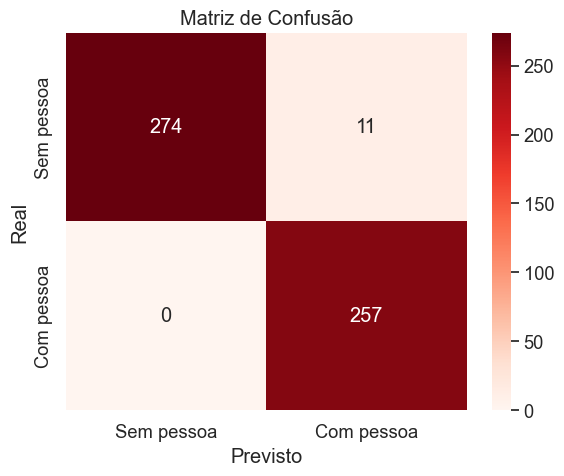

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.2)
plt.figure(figsize=(6, 5))

sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Sem pessoa", "Com pessoa"],
            yticklabels=["Sem pessoa", "Com pessoa"])

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


In [ ]:

pkl_path = path + "\\modelo_treinado.pkl"
model = joblib.load(pkl_path)

In [ ]:
# --- Carregar o novo dataset ---
# df_afinar já deve estar carregado no ambiente
X_afinar = df_afinar.drop(columns='label').values
y_afinar = df_afinar['label'].values

In [ ]:
# --- Fazer previsões ---
y_pred_afinar = model.predict(X_afinar)


# Índices dos erros
falsos_negativos = (y_afinar == 1) & (y_pred_afinar == 0)
falsos_positivos = (y_afinar == 0) & (y_pred_afinar == 1)

# Extrair exemplos incorretamente classificados
X_erros = X_afinar[falsos_negativos | falsos_positivos]
y_erros = y_afinar[falsos_negativos | falsos_positivos]

print(f"Total de exemplos a adicionar (FP + FN): {len(y_erros)}")

# --- Calcular a matriz de confusão ---
cm = confusion_matrix(y_afinar, y_pred_afinar)
print("Confusion Matrix (dataset2):")
print(cm)

In [ ]:
X_treinado_reforçado = np.vstack([X_train, X_erros])
y_treinado_reforçado = np.hstack([y_train, y_erros])

print(X_treinado_reforçado.shape, y_treinado_reforçado.shape)
display(X_treinado_reforçado.shape, y_treinado_reforçado.shape)


In [ ]:
modelo2 = skl.ensemble.RandomForestClassifier(
    min_samples_split=16,
    min_samples_leaf=4,
    max_leaf_nodes=64,
    n_estimators=150,
    random_state=200,
    max_depth=32,
    class_weight="balanced_subsample",
    criterion='entropy'
)

modelo2.fit(X_treinado_reforçado, y_treinado_reforçado)


In [ ]:
y_pred_novo = modelo2.predict(X_test)
from sklearn.metrics import balanced_accuracy_score

print("Balanced Accuracy do novo modelo:", balanced_accuracy_score(y_test, y_pred_novo))


In [ ]:
#Guarda o modelo treinado em .pkl

pkl_path = path + "\\modelo_treinado_2.pkl"

joblib.dump(model, pkl_path)
print(f"Modelo salvo em: {pkl_path}")

In [ ]:
min_samples_splits = [4, 16, 32]
min_samples_leafs = [4, 16, 32, 64]
max_leaf_nodes = [4, 16, 32, 64]
n_estimators = [100, 150, 200] #5,10,50
max_depths = [4, 16, 32]
balanced_accuracy_dict = {}


In [ ]:

run=0
balanced_accuracy_dict_modelo2 = {}

for min_samples_split in min_samples_splits:
  for min_samples_leaf in min_samples_leafs:
    for max_leaf_node in max_leaf_nodes:
      for n_estimator in n_estimators:
        for max_depth in max_depths:
          model = skl.ensemble.RandomForestClassifier(n_estimators=n_estimator,
                                                      min_samples_split=min_samples_split,
                                                      min_samples_leaf=min_samples_leaf,
                                                      max_leaf_nodes=max_leaf_node,
                                                      random_state = 200,
                                                      max_depth=max_depth,
                                                      class_weight="balanced_subsample",
                                                      criterion='entropy')
          model = model.fit(X_treinado_reforçado, y_treinado_reforçado)

          pred_test = model.predict(X_test)
          ba=skl.metrics.balanced_accuracy_score(y_test, pred_test)

          confusion_matrix_test = skl.metrics.confusion_matrix(y_test, pred_test)

          balanced_accuracy_dict[run]={'min_samples_split':min_samples_split,
                                       'min_samples_leaf':min_samples_leaf,
                                       'max_leaf_nodes':max_leaf_node,
                                       'max_depth':max_depth,
                                       'n_estimators':n_estimator,
                                       'balanced_accuracy':ba,
                                       'confusion_matrix':confusion_matrix_test}

          run +=1
          print(ba)


In [ ]:
np.savez('grid_search.npz',balanced_accuracy_dict=balanced_accuracy_dict, allow_pickle=True)

In [ ]:

param = np.load('grid_search.npz', allow_pickle=True)

balanced_accuracy_dict = param['balanced_accuracy_dict'].item()

print(balanced_accuracy_dict)

best_run = max(balanced_accuracy_dict, key=lambda k: balanced_accuracy_dict[k]['balanced_accuracy'])
print("Melhor combinação:", balanced_accuracy_dict[best_run])
